[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anmedinas/score_matching/blob/main/notebooks/train_colab.ipynb)

# Entrenamiento real en GPU (Colab) — score_matching

Este notebook **no reimplementa nada**: clona el repo real de GitHub y
ejecuta `download_data.py`, `train.py` y `train_clf.py` tal cual estan en el
repositorio, para trazabilidad limpia (el checkpoint resultante queda ligado
a un commit concreto, no a una copia pegada en una celda).

**Antes de correr**: `Entorno de ejecucion -> Cambiar tipo de entorno de
ejecucion -> GPU`.

In [13]:
import torch

print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("ADVERTENCIA: sin GPU. Entorno de ejecucion -> Cambiar tipo -> GPU.")

CUDA disponible: True
Tesla T4


## Clonar (o actualizar) el repo real

In [14]:
import os

REPO_URL = "https://github.com/anmedinas/score_matching.git"
REPO_DIR = "/content/score_matching"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("Repo ya clonado, actualizando con git pull...")
    !cd {REPO_DIR} && git pull

os.chdir(REPO_DIR)
!git log --oneline -1

Repo ya clonado, actualizando con git pull...
remote: Enumerating objects: 20, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 12 (delta 6), reused 12 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (12/12), 219.22 KiB | 7.31 MiB/s, done.
From https://github.com/anmedinas/score_matching
   b43c67e..a11e062  main       -> origin/main
Updating b43c67e..a11e062
Fast-forward
 .gitignore          |  13 +++++-
 evaluate.py         |   4 ++
 figures/logo.png    | Bin 0 -> 72189 bytes
 informe/informe.pdf | Bin 0 -> 152145 bytes
 informe/informe.tex | 127 ++++++++++++++++++++++++++++++++++++++++++++++++++++
 sample.py           |   5 +++
 train.py            |   5 +++
 train_clf.py        |   4 ++
 8 files changed, 156 insertions(+), 2 deletions(-)
 create mode 100755 figures/logo.png
 create mode 100644 informe/informe.pdf
 create mode 100644 informe/informe.tex
a11e062 (HEAD -> main, origin/main, origin/HEAD) feat: up

## Dependencias

Se instala `requirements.txt` **sin** `torch`/`torchvision`: Colab ya trae
una version con soporte CUDA preinstalada; reinstalar la version pineada del
repo (CPU por defecto desde PyPI) rompería la GPU.

In [15]:
#!grep -v -E '^torch' requirements.txt > /tmp/requirements_colab.txt
#!pip install -q -r /tmp/requirements_colab.txt

## Datos

In [16]:
!python download_data.py

## Hiperparametros (editables)

Ajusta y vuelve a correr esta celda antes de entrenar. `label_dropout_cfg`
queda en 0.1 (valor estandar en la literatura de CFG); el resto son puntos
de partida razonables para GPU, no valores finales.

In [17]:
n_epochs_diffusion = 40  #@param {type:"integer"}
n_epochs_clf = 8  #@param {type:"integer"}
batch_size = 256  #@param {type:"integer"}
lr = 3e-4  #@param {type:"number"}
lr_clf = 1e-3  #@param {type:"number"}
label_dropout_cfg = 0.1  #@param {type:"number"}
seed = 0  #@param {type:"integer"}
n_sampling_steps = 1000  #@param {type:"integer"}
w_cfg = 3.0  #@param {type:"number"}

## Entrenamiento — red condicional pura (`modelo_cond.pt`, `label_dropout=0.0`)

In [18]:
!python train.py \
  --epochs {n_epochs_diffusion} --batch-size {batch_size} --lr {lr} \
  --device cuda --seed {seed} --label-dropout 0.0 --out checkpoints

epoch 1/40  loss 0.1692
epoch 2/40  loss 0.0763
epoch 3/40  loss 0.0640
epoch 4/40  loss 0.0581
epoch 5/40  loss 0.0552
epoch 6/40  loss 0.0530
epoch 7/40  loss 0.0520
epoch 8/40  loss 0.0510
epoch 9/40  loss 0.0500
epoch 10/40  loss 0.0496
epoch 11/40  loss 0.0486
epoch 12/40  loss 0.0483
epoch 13/40  loss 0.0472
epoch 14/40  loss 0.0470
epoch 15/40  loss 0.0468
epoch 16/40  loss 0.0468
epoch 17/40  loss 0.0459
epoch 18/40  loss 0.0464
epoch 19/40  loss 0.0452
epoch 20/40  loss 0.0454
epoch 21/40  loss 0.0455
epoch 22/40  loss 0.0452
epoch 23/40  loss 0.0446
epoch 24/40  loss 0.0448
epoch 25/40  loss 0.0450
epoch 26/40  loss 0.0443
epoch 27/40  loss 0.0442
epoch 28/40  loss 0.0446
epoch 29/40  loss 0.0439
epoch 30/40  loss 0.0441
epoch 31/40  loss 0.0441
epoch 32/40  loss 0.0435
epoch 33/40  loss 0.0437
epoch 34/40  loss 0.0443
epoch 35/40  loss 0.0435
epoch 36/40  loss 0.0434
epoch 37/40  loss 0.0428
epoch 38/40  loss 0.0428
epoch 39/40  loss 0.0430
epoch 40/40  loss 0.0430
checkpoin

## Entrenamiento — red con CFG (`modelo_cfg.pt`, `label_dropout={label_dropout_cfg}`)

In [19]:
!python train.py \
  --epochs {n_epochs_diffusion} --batch-size {batch_size} --lr {lr} \
  --device cuda --seed {seed} --label-dropout {label_dropout_cfg} --out checkpoints

epoch 1/40  loss 0.1572
epoch 2/40  loss 0.0741
epoch 3/40  loss 0.0644
epoch 4/40  loss 0.0595
epoch 5/40  loss 0.0561
epoch 6/40  loss 0.0541
epoch 7/40  loss 0.0529
epoch 8/40  loss 0.0524
epoch 9/40  loss 0.0510
epoch 10/40  loss 0.0501
epoch 11/40  loss 0.0494
epoch 12/40  loss 0.0490
epoch 13/40  loss 0.0479
epoch 14/40  loss 0.0482
epoch 15/40  loss 0.0474
epoch 16/40  loss 0.0474
epoch 17/40  loss 0.0475
epoch 18/40  loss 0.0464
epoch 19/40  loss 0.0465
epoch 20/40  loss 0.0458
epoch 21/40  loss 0.0459
epoch 22/40  loss 0.0457
epoch 23/40  loss 0.0459
epoch 24/40  loss 0.0456
epoch 25/40  loss 0.0454
epoch 26/40  loss 0.0450
epoch 27/40  loss 0.0451
epoch 28/40  loss 0.0449
epoch 29/40  loss 0.0443
epoch 30/40  loss 0.0447
epoch 31/40  loss 0.0441
epoch 32/40  loss 0.0444
epoch 33/40  loss 0.0444
epoch 34/40  loss 0.0444
epoch 35/40  loss 0.0431
epoch 36/40  loss 0.0438
epoch 37/40  loss 0.0438
epoch 38/40  loss 0.0436
epoch 39/40  loss 0.0437
epoch 40/40  loss 0.0439
checkpoin

## Entrenamiento — clasificador auxiliar (`clasificador.pt`)

In [20]:
!python train_clf.py \
  --epochs {n_epochs_clf} --batch-size {batch_size} --lr {lr_clf} \
  --device cuda --seed {seed} --out checkpoints

epoch 1/8  loss 0.2472
epoch 2/8  loss 0.0617
epoch 3/8  loss 0.0427
epoch 4/8  loss 0.0358
epoch 5/8  loss 0.0289
epoch 6/8  loss 0.0239
epoch 7/8  loss 0.0197
epoch 8/8  loss 0.0167
checkpoint guardado en checkpoints/clasificador.pt
curva de perdida guardada en figures/loss/clasificador_loss.png


## Curvas de perdida (generadas por los scripts, solo se muestran aqui)

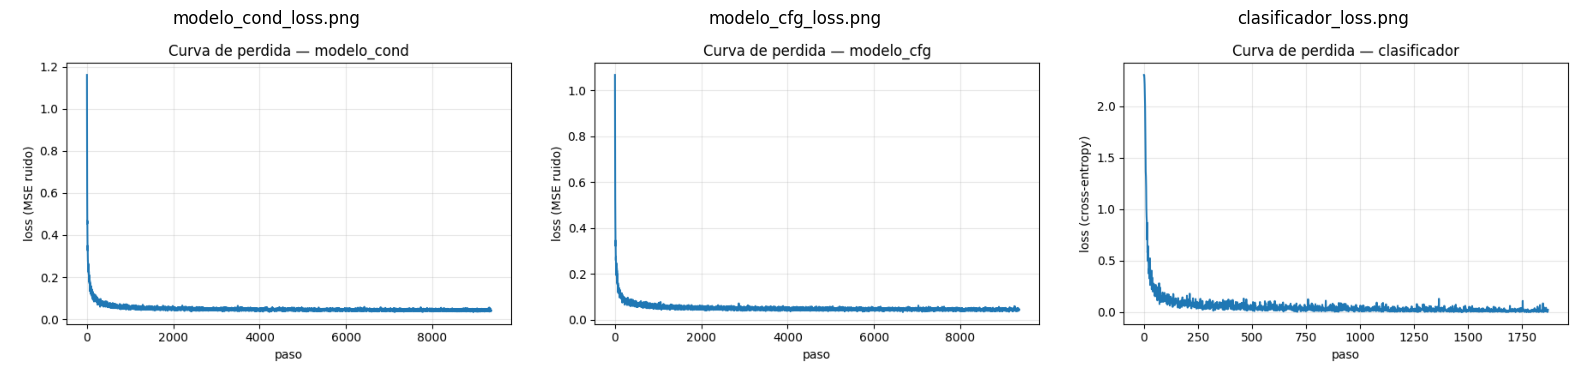

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

loss_files = ["modelo_cond_loss.png", "modelo_cfg_loss.png", "clasificador_loss.png"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, name in zip(axes, loss_files):
    ax.imshow(Image.open(f"figures/loss/{name}"))
    ax.axis("off")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Muestreo (opcional)

Requiere que `sample.py` este pusheado al repo remoto. Si todavia no lo
esta, esta celda lo detecta y avisa en vez de fallar; sube `sample.py`,
vuelve a correr la celda de `git pull` de mas arriba, y reintenta.

muestras guardadas en figures/samples/modelo_cond_w1.png
muestras guardadas en figures/samples/modelo_cfg_w1.png
muestras guardadas en figures/samples/modelo_cfg_w3.png


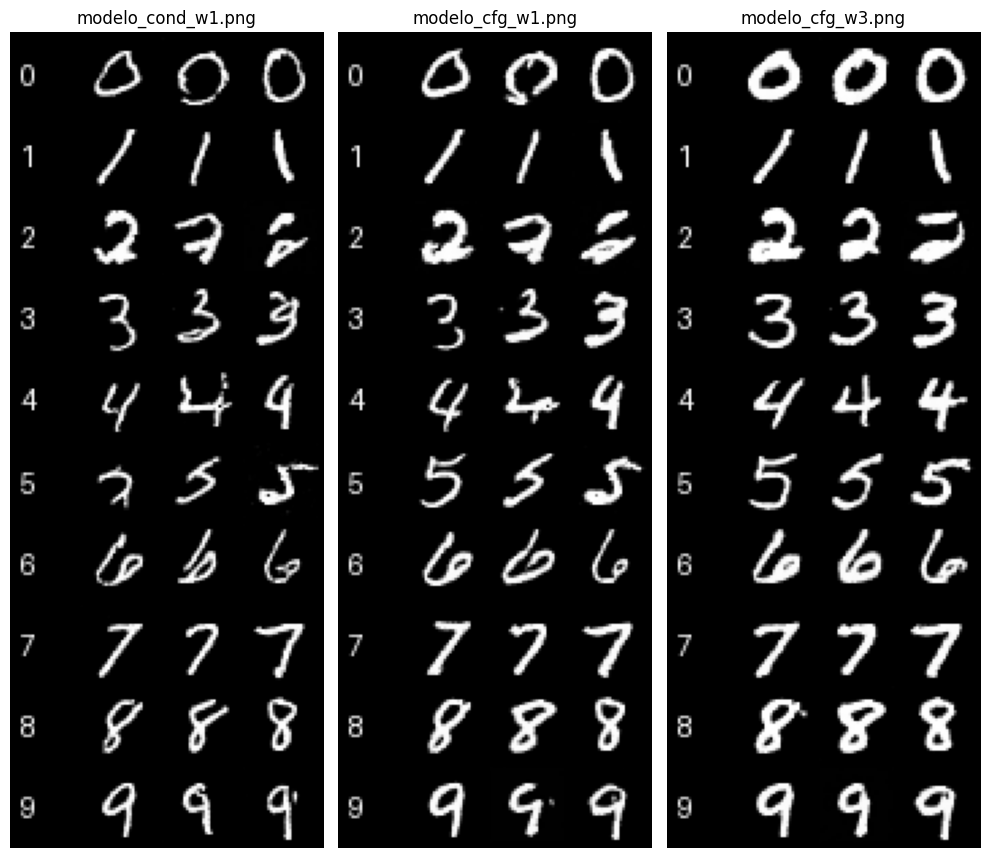

In [22]:
import os

if not os.path.exists("sample.py"):
    print("sample.py todavia no esta en el repo remoto (no fue pusheado).")
    print("Subelo, vuelve a correr la celda de clonado/pull, y reintenta esta celda.")
else:
    !python sample.py --checkpoint checkpoints/modelo_cond.pt \
      --n-steps {n_sampling_steps} --w 1.0 --n-samples 30 --device cuda \
      --seed {seed} --out figures/samples
    !python sample.py --checkpoint checkpoints/modelo_cfg.pt \
      --n-steps {n_sampling_steps} --w 1.0 --n-samples 30 --device cuda \
      --seed {seed} --out figures/samples
    !python sample.py --checkpoint checkpoints/modelo_cfg.pt \
      --n-steps {n_sampling_steps} --w {w_cfg} --n-samples 30 --device cuda \
      --seed {seed} --out figures/samples

    import matplotlib.pyplot as plt
    from PIL import Image

    sample_files = ["modelo_cond_w1.png", "modelo_cfg_w1.png", f"modelo_cfg_w{w_cfg:g}.png"]
    fig, axes = plt.subplots(1, 3, figsize=(10, 14))
    for ax, name in zip(axes, sample_files):
        ax.imshow(Image.open(f"figures/samples/{name}"))
        ax.axis("off")
        ax.set_title(name)
    plt.tight_layout()
    plt.show()

## Evaluación (`evaluate.py`)

Compara `modelo_cond` (`w=1`) vs `modelo_cfg` (`w={w_cfg}`) usando
`clasificador.pt` como juez automático: fidelidad condicional y diversidad
intra-clase, por clase y promedio. Requiere que `sample.py` **y**
`evaluate.py` estén pusheados al repo remoto (mismo chequeo defensivo que la
celda de muestreo).

tabla guardada en figures/evaluate/fidelidad_diversidad.csv
grafico guardado en figures/evaluate/fidelidad_por_clase.png
grafico guardado en figures/evaluate/diversidad_por_clase.png
modelo_cond (w=1): fidelidad promedio=0.931  diversidad promedio=17.271
modelo_cfg (w=3): fidelidad promedio=1.000  diversidad promedio=16.654


,red,w,clase,fidelidad,diversidad
0,modelo_cond (w=1),1.0,0,0.930,19.188509
1,modelo_cond (w=1),1.0,1,0.970,12.693814
2,modelo_cond (w=1),1.0,2,0.890,18.244585
3,modelo_cond (w=1),1.0,3,0.910,18.433004
4,modelo_cond (w=1),1.0,4,0.920,17.304987
5,modelo_cond (w=1),1.0,5,0.930,18.189196
6,modelo_cond (w=1),1.0,6,0.960,17.785660
7,modelo_cond (w=1),1.0,7,0.950,16.449116
8,modelo_cond (w=1),1.0,8,0.940,18.113773
9,modelo_cond (w=1),1.0,9,0.910,16.303095


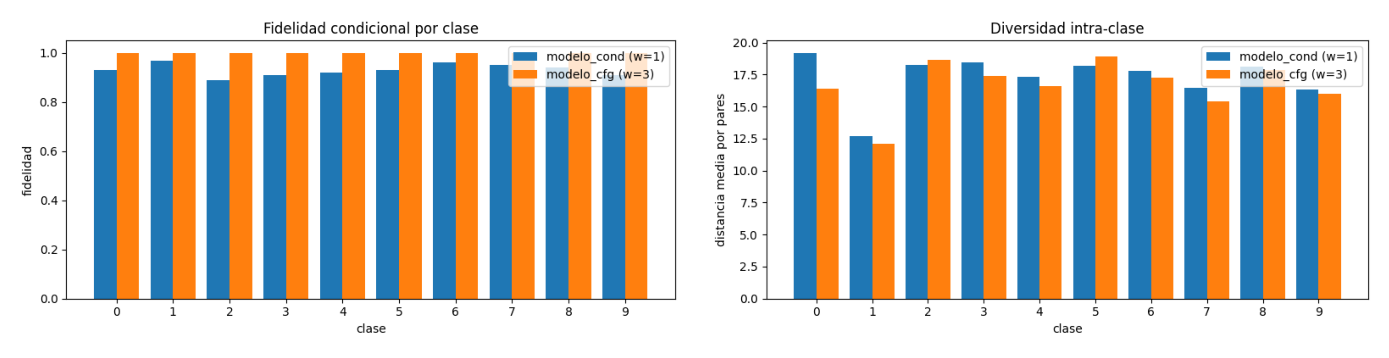

In [23]:
import os

if not (os.path.exists("sample.py") and os.path.exists("evaluate.py")):
    print("sample.py y/o evaluate.py todavia no estan en el repo remoto.")
    print("Subelos, vuelve a correr la celda de clonado/pull, y reintenta esta celda.")
else:
    !python evaluate.py --w {w_cfg} --n-samples 1000 --n-steps {n_sampling_steps} \
      --device cuda --seed {seed} --out figures/evaluate

    import pandas as pd
    import matplotlib.pyplot as plt
    from PIL import Image

    tabla = pd.read_csv("figures/evaluate/fidelidad_diversidad.csv")
    display(tabla)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].imshow(Image.open("figures/evaluate/fidelidad_por_clase.png"))
    axes[1].imshow(Image.open("figures/evaluate/diversidad_por_clase.png"))
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## Descargar resultados

Empaqueta `checkpoints/` y `figures/` en un .zip para bajarlos al equipo
local (no se hace `git push` desde aca; el repo local sigue siendo la fuente
de verdad que tu decides cuando subir).

In [24]:
from google.colab import files

!zip -r -q /content/resultados_colab.zip checkpoints figures
files.download("/content/resultados_colab.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>